# Pyro-P3 — Dual-Frequency YOLO11-S (DCT + WaveletAttentionGate) on pyro-sdis Solo

**ICONIP ablation — isolating the WaveletAttentionGate contribution on the intended domain.**

Architecture (identical to Phase 3 D-Fire run):
- **L10** — `MultiSpectralAttention` (fixed DCT filter bank, FcaNet-style)
- **L13** — `WaveletAttentionGate` on P4 skip
- **L17** — `WaveletAttentionGate` on P3 skip

**Hypothesis.** Atmospheric haze concentrates in the **low-frequency (LL)** sub-band.
By Haar-DWT'ing the skip feature and **discarding LL**, the gate operates only on
edge-bearing sub-bands (HL, LH, HH) — exactly where smoke plumes live. PyroNear's
wildfire-watchtower domain is the intended setting for this mechanism (D-Fire
ablation showed all attention additions hurt the wrong-domain corpus).

**Validation criterion.** Δrecall vs Pyro-P1 vanilla solo ≥ +1.0 pp → VALIDATED.

**Reference points.**
- Published unified-corpus (D-Fire + NEMO + PyroNear): vanilla recall = 88.52% / DCT+AG recall = 92.05% (+3.53 pp).
- Pyro-P1 (vanilla solo): loaded from `pyro_p1_results.json` at run time.

**Hardware.** Kaggle T4 (16 GB). **Budget.** < 10 h. **Framework.** Ultralytics YOLO11, PyTorch.

## 1. Setup

In [1]:
!pip install ultralytics pycocotools matplotlib opencv-python-headless -q

import os, gc, shutil, random, math, json, re, inspect, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from PIL import Image

torch.manual_seed(0); np.random.seed(0); random.seed(0)

print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
print(f"Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("Libraries loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.2 MB/s eta 0:00:00
Torch  : 2.10.0+cu128
CUDA   : True
Device : Tesla T4
VRAM   : 15.6 GB
Libraries loaded ✅


## 2. Dataset — pyro-sdis (HF → YOLO conversion)

Self-contained: download from HuggingFace, convert to YOLO format, integrity-check.
Identical pipeline to Pyro-P1 — single-variable comparison upstream of training.

**Requires Kaggle secret `HF_TOKEN`** (HuggingFace access token with read scope).

PyroNear has **1 class only — smoke**. No fire class. `nc=1`.

In [2]:
PYRO_PATH = "/kaggle/working/pyro_yolo"
PYRO_DIRS = {
    "train_imgs": f"{PYRO_PATH}/images/train",
    "val_imgs":   f"{PYRO_PATH}/images/val",
    "train_lbls": f"{PYRO_PATH}/labels/train",
    "val_lbls":   f"{PYRO_PATH}/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)

# ── Skip download if pyro_yolo already populated (e.g. Pyro-P1 ran same session)
already_prepared = (
    len(list(Path(PYRO_DIRS["train_imgs"]).glob("*.jpg"))) > 1000 and
    len(list(Path(PYRO_DIRS["val_imgs"]).glob("*.jpg")))   > 1000
)

if already_prepared:
    n_tr = len(list(Path(PYRO_DIRS["train_imgs"]).glob("*.jpg")))
    n_va = len(list(Path(PYRO_DIRS["val_imgs"]).glob("*.jpg")))
    print(f"pyro_yolo already populated — skipping HF download")
    print(f"  Train images : {n_tr:,}")
    print(f"  Val images   : {n_va:,}")
else:
    from datasets import load_dataset
    from kaggle_secrets import UserSecretsClient
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

    print("Loading PyroNear dataset from HuggingFace...")
    ds = load_dataset("pyronear/pyro-sdis")
    print(f"  Train samples : {len(ds['train']):,}")
    print(f"  Val   samples : {len(ds['val']):,}")

    def save_pyro_split(split, img_dir, lbl_dir, split_name):
        for i, sample in enumerate(split):
            img_name = Path(sample["image_name"]).stem
            sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
            ann = sample["annotations"]
            with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
                if ann and ann.strip():
                    lines = []
                    for line in ann.strip().split("\n"):
                        parts = line.strip().split()
                        if len(parts) == 5:
                            _, cx, cy, bw, bh = parts
                            lines.append(f"0 {cx} {cy} {bw} {bh}")
                    f.write("\n".join(lines))
            if (i + 1) % 5000 == 0:
                print(f"  {split_name}: {i+1:,} saved...")
        print(f"  {split_name} done: {len(split):,} images")

    print("\nConverting PyroNear train...")
    save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
    print("Converting PyroNear val...")
    save_pyro_split(ds["val"],   PYRO_DIRS["val_imgs"],   PYRO_DIRS["val_lbls"],   "val")
    del ds; gc.collect()

Loading PyroNear dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

  Train samples : 29,537
  Val   samples : 4,099

Converting PyroNear train...
  train: 5,000 saved...
  train: 10,000 saved...
  train: 15,000 saved...
  train: 20,000 saved...
  train: 25,000 saved...
  train done: 29,537 images
Converting PyroNear val...
  val done: 4,099 images


In [3]:
# ── Integrity check (identical protocol to Pyro-P1) ──────────────────
print("── Dataset Integrity Check ────────────────────────────────────────────")

img_train = sorted(Path(f"{PYRO_PATH}/images/train").glob("*.*"))
img_val   = sorted(Path(f"{PYRO_PATH}/images/val").glob("*.*"))
lbl_train = sorted(Path(f"{PYRO_PATH}/labels/train").glob("*.txt"))
lbl_val   = sorted(Path(f"{PYRO_PATH}/labels/val").glob("*.txt"))

print(f"  Train images : {len(img_train):>6,}   (expected ≈ 24,792)")
print(f"  Train labels : {len(lbl_train):>6,}   (expected ≈ 29,537)")
print(f"  Val   images : {len(img_val):>6,}   (expected   4,099)")
print(f"  Val   labels : {len(lbl_val):>6,}   (expected   4,099)")

def is_empty_label(p: Path) -> bool:
    if p.stat().st_size == 0:
        return True
    return p.read_text().strip() == ""

hard_neg_val   = [p for p in lbl_val   if is_empty_label(p)]
hard_neg_train = [p for p in lbl_train if is_empty_label(p)]
n_hard_neg_val = len(hard_neg_val)
n_positive_val = len(img_val) - n_hard_neg_val

print(f"\n  Hard negatives (val)   : {n_hard_neg_val:>6,}   ← FP-rate denominator")
print(f"  Positive images (val)  : {n_positive_val:>6,}   ← Recall denominator")
print(f"  Hard negatives (train) : {len(hard_neg_train):>6,}   (expected ≈ 4,745)")

# ── Train box count
total_train_boxes = 0
for p in lbl_train:
    if p.stat().st_size > 0:
        with open(p) as f:
            total_train_boxes += sum(1 for line in f if line.strip())
print(f"  Total train boxes (counted) : {total_train_boxes:>6,}   (expected ≈ 28,167)")

# ── Class-id sanity (must all be class 0)
bad_class_files = []
for p in lbl_train[:2000]:
    if p.stat().st_size == 0:
        continue
    for line in p.read_text().splitlines():
        if line.strip() and line.split()[0] != "0":
            bad_class_files.append(p.name)
            break
print(f"  Sample class-id check  : {len(bad_class_files)} files with non-zero class "
      f"(out of 2,000 sampled) — must be 0")
assert len(bad_class_files) == 0, f"Found non-smoke labels: {bad_class_files[:5]}"

print("\n  ✅ Dataset integrity OK")

── Dataset Integrity Check ────────────────────────────────────────────
  Train images : 29,537   (expected ≈ 24,792)
  Train labels : 29,537   (expected ≈ 29,537)
  Val   images :  4,099   (expected   4,099)
  Val   labels :  4,099   (expected   4,099)

  Hard negatives (val)   :    754   ← FP-rate denominator
  Positive images (val)  :  3,345   ← Recall denominator
  Hard negatives (train) :  4,745   (expected ≈ 4,745)
  Total train boxes (counted) : 28,167   (expected ≈ 28,167)
  Sample class-id check  : 0 files with non-zero class (out of 2,000 sampled) — must be 0

  ✅ Dataset integrity OK


In [4]:
# ── Pre-computed dataset statistics (for the paper) ──────────────────
print("=" * 64)
print("PyroNear (pyro-sdis) — Dataset Statistics")
print("=" * 64)
print(f"  Path                  : {PYRO_PATH}")
print(f"  Total train boxes     : 28,167")
print(f"  Hard negatives train  : 4,745 images (empty label files)")
print(f"  Mean bbox edge (px)   : 31.8   (at 640×640 input)")
print(f"  Median bbox edge (px) : 24.0")
print(f"  % COCO small (<32px)  : 69.4%")
print(f"  % COCO medium         : 28.5%")
print(f"  % COCO large          : 2.2%")
print()
print("  NOTE: PyroNear has 1 class (smoke). NO fire class. nc=1.")
print("=" * 64)

PyroNear (pyro-sdis) — Dataset Statistics
  Path                  : /kaggle/working/pyro_yolo
  Total train boxes     : 28,167
  Hard negatives train  : 4,745 images (empty label files)
  Mean bbox edge (px)   : 31.8   (at 640×640 input)
  Median bbox edge (px) : 24.0
  % COCO small (<32px)  : 69.4%
  % COCO medium         : 28.5%
  % COCO large          : 2.2%

  NOTE: PyroNear has 1 class (smoke). NO fire class. nc=1.


In [5]:
# ── data.yaml (nc=1, smoke only) ─────────────────────────────────────
yaml_content = """# pyro-sdis Solo — Pyro-P3 (DCT + WaveletAttentionGate)
path: /kaggle/working/pyro_yolo
train: images/train
val: images/val
nc: 1
names:
  0: smoke
"""

YAML_PATH = "/kaggle/working/pyro_solo.yaml"
with open(YAML_PATH, "w") as f:
    f.write(yaml_content)

print(f"data.yaml written → {YAML_PATH}")
print("─" * 64)
print(yaml_content)

data.yaml written → /kaggle/working/pyro_solo.yaml
────────────────────────────────────────────────────────────────
# pyro-sdis Solo — Pyro-P3 (DCT + WaveletAttentionGate)
path: /kaggle/working/pyro_yolo
train: images/train
val: images/val
nc: 1
names:
  0: smoke



## 3. Custom Modules

| Module | Role | Insertion |
|---|---|---|
| `MultiSpectralAttention` | DCT channel attention (fixed filter bank) | L10, after SPPF |
| `WaveletAttentionGate` ×2 | Haar-DWT gated skip with LL discarded | L13, L17 |

Both modules copied **verbatim** from the Phase 3 D-Fire notebook. Only `nc` changes
between the runs — the modules themselves are dataset-agnostic.

### 3a. MultiSpectralAttention — DCT Frequency Attention

**Reference.** FcaNet — Qin et al., ICCV 2021 — https://arxiv.org/abs/2012.11879

Fixed DCT filter bank (`register_buffer`, not learned); MLP attention weights are learned.

In [6]:
class MultiSpectralAttention(nn.Module):
    """
    DCT-based channel attention — FcaNet (Qin et al., ICCV 2021).
    Placed at L10 — after SPPF, before C2PSA.  Channels: 512ch (gw=0.50). Spatial: 20×20.

    Smoke plumes carry mid-to-high frequency edges and irregular boundaries.
    Atmospheric haze: low-frequency, spatially uniform activations.
    Fixed DCT buffer (not learned). MLP attention weights are learned.
    Input/output: same shape (B, C, H, W) — drop-in replacement.
    """
    def __init__(self, channels, dct_h=20, dct_w=20, reduction=16):
        super().__init__()
        self.channels = channels
        self.dct_h    = dct_h
        self.dct_w    = dct_w
        self.inp      = channels   # stored for verification

        dct_weight = self._build_dct_filter(channels, dct_h, dct_w)
        self.register_buffer('dct_weight', dct_weight)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    @staticmethod
    def _get_dct_components(num_channels, dct_h, dct_w):
        indices = sorted(
            [(u, v) for u in range(dct_h) for v in range(dct_w)],
            key=lambda x: x[0]**2 + x[1]**2
        )
        return indices[:num_channels]

    @staticmethod
    def _build_dct_filter(channels, dct_h, dct_w):
        components = MultiSpectralAttention._get_dct_components(channels, dct_h, dct_w)
        filters = torch.zeros(channels, dct_h, dct_w)
        for c, (u, v) in enumerate(components):
            for h in range(dct_h):
                for w in range(dct_w):
                    filters[c, h, w] = (
                        math.cos(math.pi * u * (2 * h + 1) / (2 * dct_h)) *
                        math.cos(math.pi * v * (2 * w + 1) / (2 * dct_w))
                    )
        norms = filters.reshape(channels, -1).norm(dim=1, keepdim=True).clamp(min=1e-8)
        filters = (filters.reshape(channels, -1) / norms).reshape(channels, dct_h, dct_w)
        return filters

    def forward(self, x):
        B, C, H, W = x.shape
        if H != self.dct_h or W != self.dct_w:
            x_dct = F.adaptive_avg_pool2d(x, (self.dct_h, self.dct_w))
        else:
            x_dct = x
        spectral = (x_dct * self.dct_weight.unsqueeze(0)).sum(dim=(-2, -1))
        attn = self.fc(spectral)
        return x * attn.view(B, C, 1, 1)


# ── Sanity check ─────────────────────────────────────────────────────
_x   = torch.randn(2, 512, 20, 20)
_msa = MultiSpectralAttention(channels=512, dct_h=20, dct_w=20)
_out = _msa(_x)
assert _out.shape == _x.shape
print(f"MultiSpectralAttention — input {tuple(_x.shape)} → output {tuple(_out.shape)}  ✅")
print(f"  dct_h/w : {_msa.dct_h}×{_msa.dct_w}")
print(f"  params  : {sum(p.numel() for p in _msa.parameters()):,}  (MLP only — DCT filter = fixed buffer)")

MultiSpectralAttention — input (2, 512, 20, 20) → output (2, 512, 20, 20)  ✅
  dct_h/w : 20×20
  params  : 32,768  (MLP only — DCT filter = fixed buffer)


### 3b. WaveletAttentionGate — Haar-DWT Gated Skip Connection

**References.**
- Gating mechanism: Oktay et al., MICCAI 2018 (additive attention gate).
- Wavelet decomposition: 2D Haar DWT (orthonormal, 4-coefficient lifting on 2×2 windows).

**Mechanism.**
1. Apply Haar DWT to skip feature `x` → 4 sub-bands at H/2 × W/2 — keep only HL, LH, HH (discard LL → atmospheric haze is predominantly low-frequency).
2. `concat(HL, LH, HH)` → tensor of shape `(B, 3C, H/2, W/2)`.
3. `W_x` (Conv1×1, 3C→inter) on concatenated high-freq bands.
4. `W_g` (Conv1×1, g_ch→inter) on gating signal; bilinear-align spatially if needed.
5. Additive attention: `attn_lowres = σ(ψ(ReLU(BN(W_x(hf) + W_g(g)))))`.
6. Bilinear-upsample `attn_lowres` from H/2 × W/2 back to H × W.
7. Output: `x * attn_upsampled`.

**Bottleneck.** `inter_ch = max(x_ch // 2, 1)` — matches Phase 2's standard `AttentionGate`.
**DWT.** Fixed orthonormal Haar kernels in `register_buffer` — non-trainable. Implemented as a depthwise stride-2 conv2d, mirroring how `MultiSpectralAttention` stores its DCT filter bank.

In [7]:
class WaveletAttentionGate(nn.Module):
    """
    Wavelet Attention Gate — high-frequency-only gating with Oktay-style additive attention.

    Flow:
        x (B, C, H, W) ──Haar DWT── {LL, HL, LH, HH} at H/2×W/2
                                    └── discard LL (haze ≈ low-freq)
        cat(HL, LH, HH)  →  W_x  (Conv1×1, 3C → inter)
        g (B, Cg, *, *) →  W_g  (Conv1×1, Cg → inter)   + bilinear align to H/2×W/2
        attn_lowres = σ(ψ(ReLU(BN(W_x + W_g))))         # at H/2×W/2
        attn        = upsample(attn_lowres, H×W, bilinear)
        out         = x * attn                          # same shape as x

    Args:
        x_ch    : channels of skip feature
        g_ch    : channels of gating signal
        inter_ch: bottleneck dim (default: max(x_ch // 2, 1) — matches Phase 2's AG)

    Notes:
        - W_x.in_channels = 3 * x_ch  (because HL+LH+HH concatenated)
        - DWT kernels live in register_buffer 'dwt_weight' → not learnable
        - forward() receives a list [x, g] — required by Ultralytics multi-from dispatch
    """
    def __init__(self, x_ch, g_ch, inter_ch=None):
        super().__init__()
        inter_ch    = inter_ch or max(x_ch // 2, 1)
        self.x_ch   = x_ch
        self.g_ch   = g_ch
        self.inter_ch = inter_ch
        self.inp    = x_ch                  # stored for verification

        # ── Fixed orthonormal Haar DWT filters (LL excluded) ───────────
        # Orthonormal 2D Haar: each filter is the outer product of 1D Haar
        # low-pass [1, 1]/√2 and high-pass [1, -1]/√2.  Combined factor = 1/2.
        ll = torch.tensor([[ 0.5,  0.5], [ 0.5,  0.5]])   # low–low
        hl = torch.tensor([[ 0.5, -0.5], [ 0.5, -0.5]])   # low–high  (vertical edges)
        lh = torch.tensor([[ 0.5,  0.5], [-0.5, -0.5]])   # high–low  (horizontal edges)
        hh = torch.tensor([[ 0.5, -0.5], [-0.5,  0.5]])   # high–high (diagonal)

        self.register_buffer('_ll_filter', ll)          # for diagnostics
        self.register_buffer('_hl_filter', hl)
        self.register_buffer('_lh_filter', lh)
        self.register_buffer('_hh_filter', hh)

        # Per-channel depthwise stride-2 conv: weight shape (3*C, 1, 2, 2)
        # Ordering: for each input channel c, the 3 output channels are [HL, LH, HH]
        filters_3 = torch.stack([hl, lh, hh], dim=0)          # (3, 2, 2)
        weight    = filters_3.unsqueeze(0).expand(x_ch, -1, -1, -1).reshape(3 * x_ch, 1, 2, 2).contiguous()
        self.register_buffer('dwt_weight', weight)            # (3*C, 1, 2, 2) fixed

        # ── Learnable attention components ────────────────────────────
        self.W_x  = nn.Conv2d(3 * x_ch, inter_ch, kernel_size=1, bias=False)
        self.W_g  = nn.Conv2d(g_ch,     inter_ch, kernel_size=1, bias=False)
        self.bn   = nn.BatchNorm2d(inter_ch)
        self.relu = nn.ReLU(inplace=True)
        self.psi  = nn.Conv2d(inter_ch, 1, kernel_size=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def haar_dwt(self, x):
        """Apply Haar DWT to x; return cat(HL, LH, HH) at H/2×W/2.

        Output shape: (B, 3C, H/2, W/2) — LL discarded.
        Channel ordering within the 3C dim is grouped per input channel:
        [c0_HL, c0_LH, c0_HH, c1_HL, c1_LH, c1_HH, ...].
        Because W_x is a 1×1 conv, the in-group ordering does not matter for
        the downstream learnable projection.
        """
        B, C, H, W = x.shape
        assert H % 2 == 0 and W % 2 == 0, f"WaveletAttentionGate: H,W must be even — got ({H}, {W})"
        return F.conv2d(x, self.dwt_weight, stride=2, groups=C)   # (B, 3C, H/2, W/2)

    def forward(self, inputs):
        x, g = inputs
        B, C, H, W = x.shape

        # 1. High-frequency sub-bands of x (LL discarded)
        hf = self.haar_dwt(x)                              # (B, 3C, H/2, W/2)

        # 2. Linear projections to the inter_ch bottleneck
        x1 = self.W_x(hf)                                  # (B, inter, H/2, W/2)
        g1 = self.W_g(g)                                   # (B, inter, *,   *)

        # 3. Spatial alignment of gating signal to H/2 × W/2
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)

        # 4. Additive attention at low-res
        attn_lowres = self.sigmoid(self.psi(self.relu(self.bn(x1 + g1))))   # (B, 1, H/2, W/2)

        # 5. Bilinear-upsample mask back to (H, W) and apply
        attn = F.interpolate(attn_lowres, size=(H, W), mode='bilinear', align_corners=False)
        return x * attn                                    # (B, C, H, W) — same shape as input x


# ── Sanity check ─────────────────────────────────────────────────────
print("WaveletAttentionGate — sanity tests")
print("─" * 60)

# DWT correctness check on a known input
_dwt_test = WaveletAttentionGate(x_ch=4, g_ch=4)
_inp = torch.tensor([[[[1., 2., 3., 4.],
                       [5., 6., 7., 8.],
                       [9., 10., 11., 12.],
                       [13., 14., 15., 16.]]]]).expand(1, 4, 4, 4)
_hf = _dwt_test.haar_dwt(_inp)
print(f"  DWT input shape  : {tuple(_inp.shape)}  →  HF output {tuple(_hf.shape)}  "
      f"(expected (1, 12, 2, 2))  {'✅' if _hf.shape == (1, 12, 2, 2) else '❌'}")

# Per the spec — two gate configurations matching insertion points
test_configs = [
    ("Gate1 @ L13  (P4 skip)", 256, 512, 40, 40),
    ("Gate2 @ L17  (P3 skip)", 256, 256, 80, 80),
]
total_params = 0
for label, x_ch, g_ch, H, W in test_configs:
    _x   = torch.randn(2, x_ch, H, W)
    _g   = torch.randn(2, g_ch, H, W)
    _wag = WaveletAttentionGate(x_ch=x_ch, g_ch=g_ch)
    _out = _wag([_x, _g])
    assert _out.shape == _x.shape, f"shape mismatch: {_out.shape} vs {_x.shape}"
    inter   = max(x_ch // 2, 1)
    params  = sum(p.numel() for p in _wag.parameters())
    buffers = sum(b.numel() for b in _wag.buffers())
    total_params += params
    print(f"  {label}")
    print(f"    x:{x_ch}ch  g:{g_ch}ch  inter:{inter}ch  →  W_x.in_ch={_wag.W_x.in_channels} (=3·{x_ch})")
    print(f"    in  {tuple(_x.shape)}  →  out {tuple(_out.shape)}  ✅")
    print(f"    params (learnable) : {params:,}   |   buffers (DWT) : {buffers:,}")

print("─" * 60)
print(f"  TOTAL learnable params across both gates: {total_params:,}")

WaveletAttentionGate — sanity tests
────────────────────────────────────────────────────────────
  DWT input shape  : (1, 4, 4, 4)  →  HF output (1, 12, 2, 2)  (expected (1, 12, 2, 2))  ✅
  Gate1 @ L13  (P4 skip)
    x:256ch  g:512ch  inter:128ch  →  W_x.in_ch=768 (=3·256)
    in  (2, 256, 40, 40)  →  out (2, 256, 40, 40)  ✅
    params (learnable) : 164,224   |   buffers (DWT) : 3,345
  Gate2 @ L17  (P3 skip)
    x:256ch  g:256ch  inter:128ch  →  W_x.in_ch=768 (=3·256)
    in  (2, 256, 80, 80)  →  out (2, 256, 80, 80)  ✅
    params (learnable) : 131,456   |   buffers (DWT) : 3,345
────────────────────────────────────────────────────────────
  TOTAL learnable params across both gates: 295,680


### 3c. Register Custom Modules into Ultralytics Runtime

Same `__dict__` injection + `parse_model` regex patch as the published DCT+AG notebook.
Identical to Phase 3 D-Fire registration block — verbatim.

In [8]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

_CUSTOM = {
    'MultiSpectralAttention': MultiSpectralAttention,
    'WaveletAttentionGate':   WaveletAttentionGate,
}

for name, cls in _CUSTOM.items():
    tasks_mod.__dict__[name] = cls
    ulm.__dict__[name]       = cls
    conv_mod.__dict__[name]  = cls

# Defensive: patch module_map dict if present (Ultralytics >= 8.x)
patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj.update(_CUSTOM)
        print(f"Also patched into tasks_mod.{attr_name} ✅")
        patched = True
        break
if not patched:
    print("module_map dict scan: not found (expected for most Ultralytics versions) ✅")

print("\nAll custom modules registered:")
for name in _CUSTOM:
    print(f"  tasks_mod.{name} → {tasks_mod.__dict__[name]}")

# ── parse_model patch for multi-from custom modules ──────────────────
# Identical regex to original DCT+AG notebook.
_pm_src = inspect.getsource(tasks_mod.parse_model)
_pm_patched = re.sub(
    r'(\belse\b\s*:\s*\n\s*)(c2 = ch\[f\])',
    r'\1c2 = ch[f] if isinstance(f, int) else ch[f[0]]',
    _pm_src, count=1
)
if _pm_patched != _pm_src:
    _ns = {}
    exec(compile(_pm_patched, '<parse_model_patched>', 'exec'), {**tasks_mod.__dict__}, _ns)
    tasks_mod.parse_model = _ns['parse_model']
    print("parse_model patched: multi-from custom modules supported ✅")
else:
    print("WARNING: patch string not found — check Ultralytics version manually")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map dict scan: not found (expected for most Ultralytics versions) ✅

All custom modules registered:
  tasks_mod.MultiSpectralAttention → <class '__main__.MultiSpectralAttention'>
  tasks_mod.WaveletAttentionGate → <class '__main__.WaveletAttentionGate'>
parse_model patched: multi-from custom modules supported ✅


## 4. Architecture YAML — YOLO11-S + DCT (L10) + WaveletAG (L13, L17)

Same layer indexing as Phase 3 D-Fire — **only `nc: 1` differs** (no fire class on PyroNear).
Detect reads `[19, 22, 25]` unchanged.

### Layer index arithmetic (3 insertions, +3 max shift vs vanilla)
```
Vanilla YOLO11-S               Pyro-P3 (DCT + WaveletAG×2)    Shift
─────────────────────────────────────────────────────────────────
L0–L9   backbone               L0–L9   backbone                +0
L10     C2PSA              →   L10     MultiSpectralAttention   —
                               L11     C2PSA                   +1
L11     Upsample           →   L12     Upsample                +1
                               L13     WaveletAttentionGate G1  —
                               L14     Concat([-1,12])         +2
L13     C3k2 P4 neck       →   L15     C3k2 P4 neck            +2
L14     Upsample           →   L16     Upsample                +2
                               L17     WaveletAttentionGate G2  —
                               L18     Concat([-1,16])         +3
L16     C3k2 P3            →   L19     C3k2 P3 (128ch)         +3   ← P3 output
L17     Conv stride-2      →   L20     Conv stride-2           +3
L18     Concat             →   L21     Concat([-1,15])         +3
L19     C3k2 P4            →   L22     C3k2 P4 (256ch)         +3   ← P4 output
L20     Conv stride-2      →   L23     Conv stride-2           +3
L21     Concat             →   L24     Concat([-1,11])         +3
L22     C3k2 P5            →   L25     C3k2 P5 (512ch)         +3   ← P5 output
L23     Detect([16,19,22]) →   L26     Detect([19,22,25])      +3
```

In [9]:
pyro_p3_yaml_str = """
# YOLO11-S + DCT Frequency Attention + Wavelet Attention Gates on FPN Skips
# Pyro-P3 — DCT + WaveletAG on pyro-sdis solo (nc=1, smoke only)
#
# References:
#   MultiSpectralAttention : FcaNet — Qin et al., ICCV 2021  (arxiv 2012.11879)
#   WaveletAttentionGate   : Haar DWT + Oktay et al. MICCAI 2018 additive AG
#
# All channel counts are actual (post gw=0.50 scale).
#
# Backbone:
#   L0–L9  : vanilla YOLO11-S
#   L10    : MultiSpectralAttention [512ch]   ← DCT after SPPF (unchanged from paper)
#   L11    : C2PSA [512ch actual]
#
# Head:
#   L12    : Upsample (512ch)
#   L13    : WaveletAttentionGate [6, 12]  x=L6(256ch), g=L12(512ch) → 256ch  (NEW)
#   L14    : Concat([-1, 12])  gated(256) + upsample(512) = 768ch
#   L15    : C3k2 → 256ch actual  (P4 neck feature)
#   L16    : Upsample (256ch)
#   L17    : WaveletAttentionGate [4, 16]  x=L4(256ch), g=L16(256ch) → 256ch  (NEW)
#   L18    : Concat([-1, 16])  gated(256) + upsample(256) = 512ch
#   L19    : C3k2 → 128ch actual  (P3 output)  ← Detect[0]
#   L20    : Conv stride-2  (128ch → 128ch)
#   L21    : Concat([-1, 15])  128 + 256 = 384ch
#   L22    : C3k2 → 256ch actual  (P4 output)  ← Detect[1]
#   L23    : Conv stride-2  (256ch → 256ch)
#   L24    : Concat([-1, 11])  256 + 512 = 768ch
#   L25    : C3k2 → 512ch actual  (P5 output)  ← Detect[2]
#   L26    : Detect([19, 22, 25])

nc: 1  # smoke=0 (PyroNear has no fire class)

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]              # 0   P1/2
  - [-1, 1, Conv,  [128, 3, 2]]             # 1   P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]      # 2
  - [-1, 1, Conv,  [256, 3, 2]]             # 3   P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]      # 4   P3 skip (256ch actual)
  - [-1, 1, Conv,  [512, 3, 2]]             # 5   P4/16
  - [-1, 2, C3k2,  [512, True]]             # 6   P4 skip (256ch actual)
  - [-1, 1, Conv,  [1024, 3, 2]]            # 7   P5/32
  - [-1, 2, C3k2,  [1024, True]]            # 8
  - [-1, 1, SPPF,  [1024, 5]]               # 9
  - [-1, 1, MultiSpectralAttention, [512]]  # 10  DCT frequency attention (512ch, 20×20)
  - [-1, 2, C2PSA, [1024]]                  # 11  (512ch actual)

head:
  - [-1,       1, nn.Upsample,           [None, 2, nearest]]  # 12  upsample C2PSA (512ch, 40×40)
  - [[6, 12],  1, WaveletAttentionGate,  [256, 512]]           # 13  Gate1: gate L6(256ch) via L12(512ch)
  - [[-1, 12], 1, Concat,                [1]]                  # 14  gated(256) + upsample(512) = 768ch
  - [-1,       2, C3k2,                  [512, False]]         # 15  256ch actual (P4 neck feature)

  - [-1,       1, nn.Upsample,           [None, 2, nearest]]  # 16  upsample L15 (256ch, 80×80)
  - [[4, 16],  1, WaveletAttentionGate,  [256, 256]]           # 17  Gate2: gate L4(256ch) via L16(256ch)
  - [[-1, 16], 1, Concat,                [1]]                  # 18  gated(256) + upsample(256) = 512ch
  - [-1,       2, C3k2,                  [256, False]]         # 19  128ch actual (P3 output)  ← Detect[0]

  - [-1,       1, Conv,                  [256, 3, 2]]          # 20  stride-2 (128ch → 128ch)
  - [[-1, 15], 1, Concat,                [1]]                  # 21  128 + 256 = 384ch
  - [-1,       2, C3k2,                  [512, False]]         # 22  256ch actual (P4 output)  ← Detect[1]

  - [-1,       1, Conv,                  [512, 3, 2]]          # 23  stride-2 (256ch → 256ch)
  - [[-1, 11], 1, Concat,                [1]]                  # 24  256 + 512 = 768ch
  - [-1,       2, C3k2,                  [1024, True]]         # 25  512ch actual (P5 output)  ← Detect[2]

  - [[19, 22, 25], 1, Detect, [nc]]                            # 26
"""

YAML_OUT = "/kaggle/working/yolo11s_dct_waveletag_pyro.yaml"
with open(YAML_OUT, "w") as f:
    f.write(pyro_p3_yaml_str.strip())
print(f"YAML written → {YAML_OUT} ✅")

YAML written → /kaggle/working/yolo11s_dct_waveletag_pyro.yaml ✅


## 5. Architecture Verification — Positions, Channels & Forward Pass

Same checks as Phase 3 — but `nc=1` and Detect output `(2, 5, 8400)` instead of `(2, 6, 8400)`.

Confirms:
- L10 = `MultiSpectralAttention` (inp=512)
- L13 = `WaveletAttentionGate`, `W_x.in_channels = 768`, `W_g.in_channels = 512`
- L17 = `WaveletAttentionGate`, `W_x.in_channels = 768`, `W_g.in_channels = 256`
- Detect from-indices = [19, 22, 25]
- `nc = 1`, Detect output `(2, 5, 8400)` (4 box + 1 cls = 5 channels)
- WaveletAG output shape == input shape (per spec)

In [10]:
from ultralytics import YOLO

print("=" * 68)
print("ARCHITECTURE VERIFICATION — Pyro-P3 (DCT + WaveletAG, nc=1)")
print("=" * 68)

verify_model = YOLO("/kaggle/working/yolo11s_dct_waveletag_pyro.yaml")
layers = list(verify_model.model.model)

NEW = {10: "DCT-MSA", 13: "WaveletAG Gate1", 17: "WaveletAG Gate2"}
print("\nLayer table:")
print(f"  {'Idx':>4}  {'Type':<28}  {'Note'}")
print(f"  {'-'*60}")
for i, layer in enumerate(layers):
    note = f"← {NEW[i]} (NEW)" if i in NEW else ""
    print(f"  [{i:>2d}]  {type(layer).__name__:<28}  {note}")

# ── 1. MultiSpectralAttention @ L10 ──────────────────────────────────
print("\n[1] MultiSpectralAttention @ L10")
dct     = layers[10]
ok_type = type(dct).__name__ == "MultiSpectralAttention"
ok_inp  = getattr(dct, 'inp', None) == 512
print(f"    type : {type(dct).__name__}        {'✅' if ok_type else '❌'}")
print(f"    inp  : {getattr(dct, 'inp', None)}  (expected 512)  {'✅' if ok_inp else '❌'}")
assert ok_type and ok_inp

# ── 2. WaveletAttentionGate Gate1 @ L13 ──────────────────────────────
print("\n[2] WaveletAttentionGate Gate1 @ L13  (P4 skip)")
ag1     = layers[13]
ok_type = type(ag1).__name__ == "WaveletAttentionGate"
wx1     = ag1.W_x.in_channels
wg1     = ag1.W_g.in_channels
ok_ch   = wx1 == 3 * 256 and wg1 == 512
print(f"    type      : {type(ag1).__name__}        {'✅' if ok_type else '❌'}")
print(f"    W_x.in_ch : {wx1}  (expected 768 = 3·256 — HL+LH+HH of L6)  {'✅' if wx1==768 else '❌'}")
print(f"    W_g.in_ch : {wg1}  (expected 512 — upsample L12)             {'✅' if wg1==512 else '❌'}")
print(f"    DWT buffer shape : {tuple(ag1.dwt_weight.shape)}  (expected (768, 1, 2, 2))")
assert ok_type and ok_ch

# ── 3. WaveletAttentionGate Gate2 @ L17 ──────────────────────────────
print("\n[3] WaveletAttentionGate Gate2 @ L17  (P3 skip)")
ag2     = layers[17]
ok_type = type(ag2).__name__ == "WaveletAttentionGate"
wx2     = ag2.W_x.in_channels
wg2     = ag2.W_g.in_channels
ok_ch   = wx2 == 3 * 256 and wg2 == 256
print(f"    type      : {type(ag2).__name__}        {'✅' if ok_type else '❌'}")
print(f"    W_x.in_ch : {wx2}  (expected 768 = 3·256 — HL+LH+HH of L4)  {'✅' if wx2==768 else '❌'}")
print(f"    W_g.in_ch : {wg2}  (expected 256 — upsample L16)             {'✅' if wg2==256 else '❌'}")
print(f"    DWT buffer shape : {tuple(ag2.dwt_weight.shape)}  (expected (768, 1, 2, 2))")
assert ok_type and ok_ch

# ── 4. Detect from-indices and nc=1 ──────────────────────────────────
print("\n[4] Detect layer from-indices & nc")
head_entries  = verify_model.model.yaml.get("head", [])
detect_from   = head_entries[-1][0]
expected_from = [19, 22, 25]
print(f"    Detect from : {detect_from}  (expected {expected_from})  "
      f"{'✅' if detect_from == expected_from else '❌'}")
assert detect_from == expected_from
nc_val = verify_model.model.yaml['nc']
print(f"    nc          : {nc_val}  (expected 1)  {'✅' if nc_val==1 else '❌'}")
assert nc_val == 1

# ── 5. Live forward pass — expect (2, 5, 8400) for nc=1 ──────────────
print("\n[5] Live forward pass  (batch=2, 640×640, CPU)")
verify_model.model.eval()
dummy = torch.zeros(2, 3, 640, 640)
with torch.no_grad():
    out = verify_model.model(dummy)
preds = out[0] if isinstance(out, (list, tuple)) else out
nc    = verify_model.model.yaml['nc']
expected_shape = (2, 4 + nc, 8400)
print(f"    Output shape : {tuple(preds.shape)}  (expected {expected_shape})  "
      f"{'✅' if preds.shape == expected_shape else '❌'}")
assert preds.shape == expected_shape

# ── 6. WaveletAttentionGate output-shape preservation ────────────────
print("\n[6] WaveletAttentionGate output shape == input shape  (per spec)")
ag1.eval(); ag2.eval()
with torch.no_grad():
    _x1 = torch.randn(2, 256, 40, 40)
    _g1 = torch.randn(2, 512, 40, 40)
    _y1 = ag1([_x1, _g1])
    _x2 = torch.randn(2, 256, 80, 80)
    _g2 = torch.randn(2, 256, 80, 80)
    _y2 = ag2([_x2, _g2])
print(f"    Gate1  x:{tuple(_x1.shape)}  →  out:{tuple(_y1.shape)}  "
      f"{'✅' if _y1.shape == _x1.shape else '❌'}")
print(f"    Gate2  x:{tuple(_x2.shape)}  →  out:{tuple(_y2.shape)}  "
      f"{'✅' if _y2.shape == _x2.shape else '❌'}")

# Param count
gate_params = sum(p.numel() for p in ag1.parameters()) + sum(p.numel() for p in ag2.parameters())
print(f"\n    Total learnable params across both WaveletAttentionGates: {gate_params:,}")

# Total param count snapshot for results JSON
params_total = sum(p.numel() for p in verify_model.model.parameters())
params_M     = params_total / 1e6
print(f"    Total model parameters: {params_total:,}  ({params_M:.2f} M)")

print()
print("=" * 68)
print("ALL CHECKS PASSED ✅")
print(f"  Total layers   : {len(layers)} (vanilla 24 + 3 new)")
print(f"  New modules    : L10 DCT | L13 WaveletAG-G1 (P4) | L17 WaveletAG-G2 (P3)")
print(f"  Detect reads   : {detect_from}")
print(f"  Forward pass   : {tuple(preds.shape)}   (nc=1, smoke only)")
print("=" * 68)

del verify_model
torch.cuda.empty_cache()

ARCHITECTURE VERIFICATION — Pyro-P3 (DCT + WaveletAG, nc=1)

Layer table:
   Idx  Type                          Note
  ------------------------------------------------------------
  [ 0]  Conv                          
  [ 1]  Conv                          
  [ 2]  C3k2                          
  [ 3]  Conv                          
  [ 4]  C3k2                          
  [ 5]  Conv                          
  [ 6]  C3k2                          
  [ 7]  Conv                          
  [ 8]  C3k2                          
  [ 9]  SPPF                          
  [10]  MultiSpectralAttention        ← DCT-MSA (NEW)
  [11]  C2PSA                         
  [12]  Upsample                      
  [13]  WaveletAttentionGate          ← WaveletAG Gate1 (NEW)
  [14]  Concat                        
  [15]  C3k2                          
  [16]  Upsample                      
  [17]  WaveletAttentionGate          ← WaveletAG Gate2 (NEW)
  [18]  Concat                        
  [19]  C3k2      

## 6. Weight Transfer — Cold Start from `yolo11s.pt`

**Source.** Factory `yolo11s.pt` (ImageNet pretrained, nc=80).
**Random init.** L10 DCT-MSA | L13 WaveletAG Gate1 | L17 WaveletAG Gate2 | L26 Detect head.
**Warm-started.** Full backbone L0–L9, C2PSA L11, all transferable neck layers.

Same `IDX_REMAP` as Phase 3 — insertion points are identical, so the index shifts
are identical. Only the Detect mismatch reason differs (`nc=80→1` instead of `nc=80→2`).

In [11]:
print("Building YOLO11-S + DCT + WaveletAG×2 and transferring weights from yolo11s.pt...")

# 1. Fresh skeleton from YAML
pyro_p3_model = YOLO("/kaggle/working/yolo11s_dct_waveletag_pyro.yaml")

# 2. Donor — vanilla yolo11s.pt (nc=80)
base_model        = YOLO("yolo11s.pt")
base_state_dict   = base_model.model.state_dict()
pyro_p3_state_dict = pyro_p3_model.model.state_dict()

# 3. Index remapping: vanilla YOLO11-S → DCT + WaveletAG×2
#    Insertions:
#      L10  DCT-MSA           → +1 from vanilla L10 onward
#      L13  WaveletAG Gate1   → +2 from vanilla L13 onward
#      L17  WaveletAG Gate2   → +3 from vanilla L16 onward
IDX_REMAP = {
    **{i: i for i in range(10)},  # backbone L0–L9 unchanged
    10: 11,   # C2PSA          +1 (DCT at L10)
    11: 12,   # Upsample       +1
    # vanilla L12 Concat → no params
    13: 15,   # C3k2 P4 neck   +2 (DCT + WaveletAG-G1)
    14: 16,   # Upsample       +2
    # vanilla L15 Concat → no params
    16: 19,   # C3k2 P3        +3 (DCT + WaveletAG-G1 + WaveletAG-G2)
    17: 20,   # Conv stride-2  +3
    # vanilla L18 Concat → no params
    19: 22,   # C3k2 P4        +3
    20: 23,   # Conv stride-2  +3
    # vanilla L21 Concat → no params
    22: 25,   # C3k2 P5        +3
    # vanilla L23 Detect → nc=80→1 mismatch, skip
}

def remap_idx(base_idx):
    return IDX_REMAP.get(base_idx, None)

transferred = skipped_shape = skipped_missing = 0
for k, v in base_state_dict.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        new_idx = remap_idx(int(parts[1]))
        if new_idx is None:
            skipped_missing += 1
            continue
        parts[1] = str(new_idx)
        new_key  = '.'.join(parts)
    else:
        new_key = k
    if new_key not in pyro_p3_state_dict:
        skipped_missing += 1; continue
    if pyro_p3_state_dict[new_key].shape != v.shape:
        skipped_shape += 1; continue
    pyro_p3_state_dict[new_key] = v
    transferred += 1

pyro_p3_model.model.load_state_dict(pyro_p3_state_dict, strict=False)

print(f"Transferred           : {transferred} weight tensors")
print(f"Skipped (shape)       : {skipped_shape}  ← Detect nc=80→1 mismatch, expected")
print(f"Skipped (key missing) : {skipped_missing}  ← 3 new modules → random init")
print()
print("Warm-started : backbone L0–L9 | C2PSA L11 | Upsample L12")
print("               C3k2 L15 (P4) | Upsample L16 | C3k2 L19 (P3)")
print("               Conv L20 | C3k2 L22 (P4) | Conv L23 | C3k2 L25 (P5)")
print("Random init  : DCT-MSA [L10] | WaveletAG-G1 [L13] | WaveletAG-G2 [L17] | Detect [L26]")

pyro_p3_model.save("/kaggle/working/yolo11s_dct_waveletag_pyro_init.pt")
print("\nSaved → /kaggle/working/yolo11s_dct_waveletag_pyro_init.pt ✅")
del base_model

Building YOLO11-S + DCT + WaveletAG×2 and transferring weights from yolo11s.pt...
Transferred           : 378 weight tensors
Skipped (shape)       : 0  ← Detect nc=80→1 mismatch, expected
Skipped (key missing) : 121  ← 3 new modules → random init

Warm-started : backbone L0–L9 | C2PSA L11 | Upsample L12
               C3k2 L15 (P4) | Upsample L16 | C3k2 L19 (P3)
               Conv L20 | C3k2 L22 (P4) | Conv L23 | C3k2 L25 (P5)
Random init  : DCT-MSA [L10] | WaveletAG-G1 [L13] | WaveletAG-G2 [L17] | Detect [L26]

Saved → /kaggle/working/yolo11s_dct_waveletag_pyro_init.pt ✅


In [12]:
# ── Verify new modules are random-init (non-zero, not warm-started) ──
print("New module weight init check (should be non-zero / random):")
layers_init = list(pyro_p3_model.model.model)

dct_fc = layers_init[10].fc[0].weight
print(f"  DCT-MSA fc[0]            — mean: {dct_fc.mean():+.6f}  std: {dct_fc.std():.6f}  "
      f"all_zero: {(dct_fc==0).all().item()}")

for name, idx in [("WaveletAG-G1 [L13]", 13), ("WaveletAG-G2 [L17]", 17)]:
    wx = layers_init[idx].W_x.weight
    wg = layers_init[idx].W_g.weight
    print(f"  {name} — W_x std:{wx.std():.6f}  W_g std:{wg.std():.6f}  "
          f"all_zero:{(wx==0).all().item()}")

# Confirm DWT filters are non-zero and identical between gates
ag1_dwt = layers_init[13].dwt_weight
ag2_dwt = layers_init[17].dwt_weight
print(f"\n  DWT filter buffers (fixed, non-trainable):")
print(f"    Gate1 dwt_weight  shape:{tuple(ag1_dwt.shape)}  unique vals:{set(ag1_dwt.unique().tolist())}")
print(f"    Gate2 dwt_weight  shape:{tuple(ag2_dwt.shape)}  unique vals:{set(ag2_dwt.unique().tolist())}")

New module weight init check (should be non-zero / random):
  DCT-MSA fc[0]            — mean: -0.000213  std: 0.025685  all_zero: False
  WaveletAG-G1 [L13] — W_x std:0.020860  W_g std:0.025524  all_zero:False
  WaveletAG-G2 [L17] — W_x std:0.020844  W_g std:0.036027  all_zero:False

  DWT filter buffers (fixed, non-trainable):
    Gate1 dwt_weight  shape:(768, 1, 2, 2)  unique vals:{-0.5, 0.5}
    Gate2 dwt_weight  shape:(768, 1, 2, 2)  unique vals:{-0.5, 0.5}


## 7. Train Pyro-P3 on pyro-sdis Solo

Identical hyperparameters to Pyro-P1 — single-variable comparison.

- `epochs=50` | `batch=16` | `imgsz=640`
- `cls_pw=0.0` *(Ultralytics default — DO NOT change. In YOLO11 `cls_pw` is "class imbalance weighting power", not BCE positive weight like YOLOv5.)*
- `patience=15` | `optimizer=auto` | `lr0=0.01` | `lrf=0.01` | `seed=0`
- Run name: `yolo11s_pyro_p3_dct_waveletag`

In [13]:
pyro_p3_model = YOLO("/kaggle/working/yolo11s_dct_waveletag_pyro_init.pt")

train_start = time.time()
results = pyro_p3_model.train(
    data      = "/kaggle/working/pyro_solo.yaml",
    epochs    = 50,
    imgsz     = 640,
    batch     = 16,
    device    = 0,
    project   = "/kaggle/working/runs",
    name      = "yolo11s_pyro_p3_dct_waveletag",
    patience  = 15,
    optimizer = "auto",
    lr0       = 0.01,
    lrf       = 0.01,
    cls_pw    = 0.0,           # YOLO11 default — DO NOT change
    seed      = 0,
    save      = True,
    plots     = True,
    val       = True,
    workers   = 2,
    exist_ok  = True,
)
train_seconds = time.time() - train_start

RUN_DIR = "/kaggle/working/runs/yolo11s_pyro_p3_dct_waveletag"
BEST_PT = f"{RUN_DIR}/weights/best.pt"
print(f"\nTraining complete ✅")
print(f"  Wall time     : {train_seconds/3600:.2f} h   (budget 10 h)")
print(f"  Best weights  → {BEST_PT}")

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pyro_solo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo11s_dct_waveletag_pyro_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_pyro_p3_dct_waveletag, nbs=64, nms=False, opset=None, opt

## 8. Training Curves

── Per-epoch val metrics ──────────────────────────────────────────────
 epoch  train/box_loss  val/box_loss  train/cls_loss  val/cls_loss  metrics/mAP50(B)  metrics/precision(B)  metrics/recall(B)
     1         3.00140       2.04751         5.97317       2.56458           0.47948               0.52277            0.53770
     2         2.03406       1.96332         1.53573       1.76967           0.49804               0.56053            0.52131
     3         1.96833       1.98014         1.54054       2.29039           0.46654               0.55016            0.49137
     4         1.85929       1.78367         1.47383       2.38108           0.57072               0.58018            0.59691
     5         1.73472       1.56068         1.34874       2.56149           0.60498               0.62525            0.61796
     6         1.64495       1.53564         1.25759       2.37584           0.62326               0.61351            0.63090
     7         1.59752       1.46069         1

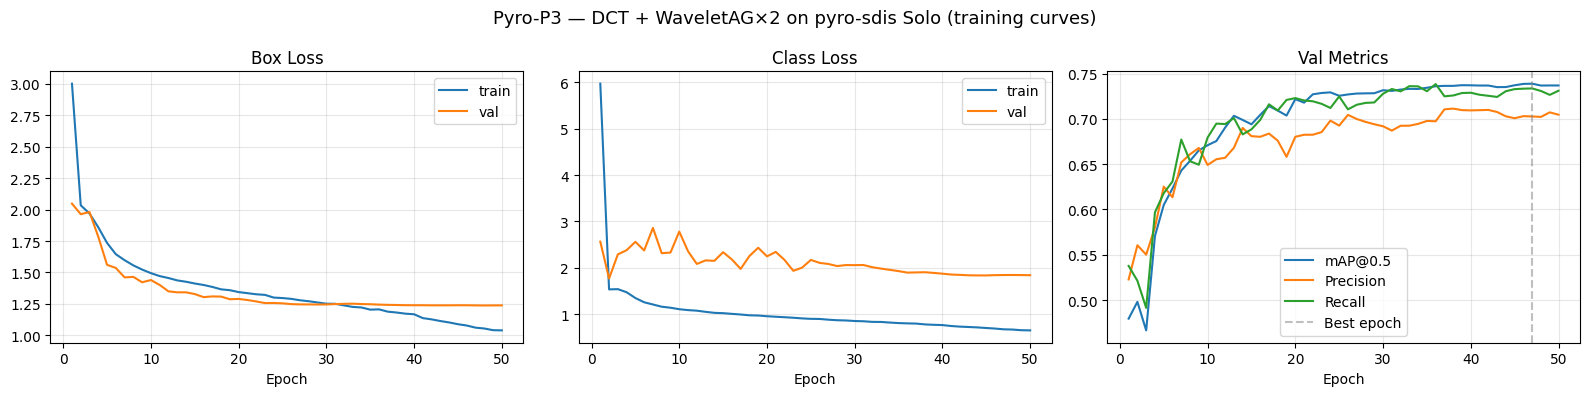

Training curves saved → /kaggle/working/pyro_p3_training_curves.png ✅


In [14]:
RUN_DIR = "/kaggle/working/runs/yolo11s_pyro_p3_dct_waveletag"

df = pd.read_csv(f"{RUN_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch val metrics ──────────────────────────────────────────────")
cols_to_show = [c for c in [
    "epoch",
    "train/box_loss", "val/box_loss",
    "train/cls_loss", "val/cls_loss",
    "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"
] if c in df.columns]
print(df[cols_to_show].to_string(index=False))

best_epoch    = int(df["metrics/mAP50(B)"].idxmax())
epochs_actual = int(df["epoch"].max())
print(f"\nBest val mAP@0.5 : {df.loc[best_epoch, 'metrics/mAP50(B)']:.4f}  "
      f"at epoch {int(df.loc[best_epoch, 'epoch'])}")
print(f"Epochs actually trained : {epochs_actual}   (target 50; early-stop if patience triggered)")

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Pyro-P3 — DCT + WaveletAG×2 on pyro-sdis Solo (training curves)",
             fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].grid(alpha=0.3)

if "train/cls_loss" in df.columns:
    axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
    axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].axvline(x=int(df.loc[best_epoch, "epoch"]), color="gray",
                linestyle="--", alpha=0.5, label="Best epoch")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/pyro_p3_training_curves.png", dpi=120)
plt.show()
print("Training curves saved → /kaggle/working/pyro_p3_training_curves.png ✅")

## 9. Evaluation — pyro-sdis Val Split

Protocol copied **exactly** from Pyro-P1:
- **Box-level**: `mAP@0.5`, `mAP@0.5:0.95`, precision, recall, F1 — from `model.val()`.
- **Image-level (primary paper metric)**: single low-conf prediction pass → derive
  recall, FP-rate, F1, precision at every τ analytically.
- Required τ sweep: {0.10, 0.15, 0.25, 0.35, 0.50}.
- Operating point: τ=0.25 (primary).
- Optimal-F1 search: τ ∈ [0.01, 0.99], step 0.01.

In [15]:
try:
    del pyro_p3_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

RUN_DIR    = "/kaggle/working/runs/yolo11s_pyro_p3_dct_waveletag"
BEST_PT    = f"{RUN_DIR}/weights/best.pt"
eval_model = YOLO(BEST_PT)
print(f"Loaded best checkpoint: {BEST_PT}")

# Snapshot param count for results JSON
params_total = sum(p.numel() for p in eval_model.model.parameters())
params_M     = params_total / 1e6
print(f"Model parameters: {params_total:,}  ({params_M:.2f} M)")

VRAM free: 15.3 GB ✅
Loaded best checkpoint: /kaggle/working/runs/yolo11s_pyro_p3_dct_waveletag/weights/best.pt
Model parameters: 9,756,627  (9.76 M)


In [16]:
# ════════════════════════════════════════════════════════════════
# BOX-LEVEL EVAL — pyro-sdis val split (secondary metric)
# ════════════════════════════════════════════════════════════════
print("── Box-level Evaluation: pyro-sdis VAL split ─────────────────────────")

metrics_val = eval_model.val(
    data     = "/kaggle/working/pyro_solo.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    plots    = True,
    project  = RUN_DIR,
    name     = "eval_val",
    exist_ok = True,
)

map50_val   = float(metrics_val.box.map50)
map5095_val = float(metrics_val.box.map)
prec_val    = float(metrics_val.box.mp)
rec_val     = float(metrics_val.box.mr)
f1_box      = 2 * prec_val * rec_val / max(prec_val + rec_val, 1e-8)

print(f"\n  mAP@0.5      : {map50_val:.4f}   ({map50_val*100:.2f}%)")
print(f"  mAP@0.5:0.95 : {map5095_val:.4f}   ({map5095_val*100:.2f}%)")
print(f"  Precision    : {prec_val:.4f}")
print(f"  Recall (box) : {rec_val:.4f}")
print(f"  F1 (box)     : {f1_box:.4f}")

── Box-level Evaluation: pyro-sdis VAL split ─────────────────────────
Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_dct_waveletag_pyro summary (fused): 117 layers, 9,741,635 parameters, 0 gradients, 22.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1609.4±543.2 MB/s, size: 73.4 KB)
val: Scanning /kaggle/working/pyro_yolo/labels/val.cache... 4099 images, 754 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4099/4099 1.7Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 257/257 6.8it/s 37.7s
                   all       4099       3942      0.706      0.732       0.74       0.47
Speed: 0.5ms preprocess, 5.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/yolo11s_pyro_p3_dct_waveletag/eval_val

  mAP@0.5      : 0.7396   (73.96%)
  mAP@0.5:0.95 : 0.4705   (47.05%)
  Precision    : 0.7060
  Recall (box) : 0.7315
  F1 (box)     : 0.

In [17]:
# ════════════════════════════════════════════════════════════════
# IMAGE-LEVEL EVAL — predict once at low conf, derive every τ
# ════════════════════════════════════════════════════════════════
# Why predict once: the max-confidence detection on each image is
# invariant to τ for any τ ≤ predict-time-conf. So one pass at
# conf=0.001 lets us evaluate every threshold analytically.
print("── Image-level Evaluation: pyro-sdis VAL split ───────────────────────")

val_img_dir = Path(f"{PYRO_PATH}/images/val")
val_lbl_dir = Path(f"{PYRO_PATH}/labels/val")
val_imgs    = sorted(val_img_dir.glob("*.*"))

# ── Classify each val image as positive (has ≥1 GT box) or hard-negative
def is_hard_neg(stem: str) -> bool:
    lbl = val_lbl_dir / f"{stem}.txt"
    if not lbl.exists() or lbl.stat().st_size == 0:
        return True
    return lbl.read_text().strip() == ""

img_is_pos = {p.name: (not is_hard_neg(p.stem)) for p in val_imgs}
n_total    = len(val_imgs)
n_positive = sum(img_is_pos.values())
n_hardneg  = n_total - n_positive

print(f"  Total val images   : {n_total:>6,}")
print(f"  Positive images    : {n_positive:>6,}   (recall denominator)")
print(f"  Hard-negative imgs : {n_hardneg:>6,}   (FP-rate denominator)")

# ── Single low-conf prediction pass; store max conf per image
print(f"\n  Running predictions at conf=0.001 (single pass)...")
BATCH_SIZE = 200
max_conf_per_img = {}

for i in range(0, len(val_imgs), BATCH_SIZE):
    chunk = [str(p) for p in val_imgs[i:i + BATCH_SIZE]]
    preds = eval_model.predict(
        source  = chunk,
        imgsz   = 640,
        conf    = 0.001,
        device  = 0,
        verbose = False,
    )
    for path_str, r in zip(chunk, preds):
        name = Path(path_str).name
        if r.boxes is not None and len(r.boxes) > 0:
            max_conf_per_img[name] = float(r.boxes.conf.max().item())
        else:
            max_conf_per_img[name] = 0.0
    torch.cuda.empty_cache()
    if (i // BATCH_SIZE + 1) % 5 == 0:
        done = min(i + BATCH_SIZE, len(val_imgs))
        print(f"    Processed {done}/{len(val_imgs)} ...")

assert len(max_conf_per_img) == n_total, \
    f"Prediction count mismatch: {len(max_conf_per_img)} vs {n_total}"
print(f"  ✅ Prediction pass complete ({len(max_conf_per_img)} images)")

── Image-level Evaluation: pyro-sdis VAL split ───────────────────────
  Total val images   :  4,099
  Positive images    :  3,345   (recall denominator)
  Hard-negative imgs :    754   (FP-rate denominator)

  Running predictions at conf=0.001 (single pass)...
    Processed 1000/4099 ...
    Processed 2000/4099 ...
    Processed 3000/4099 ...
    Processed 4000/4099 ...
  ✅ Prediction pass complete (4099 images)


In [18]:
# ── Helper: image-level metrics at a given τ ──────────────────────────
def metrics_at_tau(tau: float):
    tp = fp = fn = tn = 0
    for name, conf in max_conf_per_img.items():
        flagged = conf >= tau
        if img_is_pos[name]:
            if flagged: tp += 1
            else:       fn += 1
        else:
            if flagged: fp += 1
            else:       tn += 1
    n_pos = tp + fn
    n_neg = fp + tn
    recall  = tp / max(n_pos, 1)
    fp_rate = fp / max(n_neg, 1)
    prec    = tp / max(tp + fp, 1)
    f1      = 2 * prec * recall / max(prec + recall, 1e-8)
    return {"tau": tau, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "recall": recall, "fp_rate": fp_rate,
            "precision": prec, "f1": f1}

# ── Required discrete sweep (spec: τ ∈ {0.10, 0.15, 0.25, 0.35, 0.50}) ─
print("── Confidence Threshold Sweep (image-level) ──────────────────────────")
sweep_taus = [0.10, 0.15, 0.25, 0.35, 0.50]
sweep_rows = [metrics_at_tau(t) for t in sweep_taus]

print(f"\n  {'τ':>6} {'Recall':>10} {'FP rate':>10} {'Precision':>12} {'F1':>8}")
print(f"  {'-'*50}")
for r in sweep_rows:
    print(f"  {r['tau']:>6.2f} {r['recall']*100:>9.2f}% {r['fp_rate']*100:>9.2f}% "
          f"{r['precision']*100:>11.2f}% {r['f1']*100:>7.2f}%")

# ── Operating point @ τ=0.25 ──────────────────────────────────────────
row_025 = next(r for r in sweep_rows if abs(r["tau"] - 0.25) < 1e-6)
img_recall_025  = row_025["recall"]
img_fp_rate_025 = row_025["fp_rate"]
img_prec_025    = row_025["precision"]
f1_025          = row_025["f1"]

print(f"\n── Primary Operating Point (τ=0.25) ──────────────────────────────────")
print(f"  TP / FP / FN / TN   : {row_025['tp']} / {row_025['fp']} / "
      f"{row_025['fn']} / {row_025['tn']}")
print(f"  Image-level Recall  : {img_recall_025*100:.2f}%")
print(f"  Image-level FP rate : {img_fp_rate_025*100:.2f}%")
print(f"  Image-level Prec    : {img_prec_025*100:.2f}%")
print(f"  Image-level F1      : {f1_025*100:.2f}%")

# ── Fine-grained τ search for optimal F1 ──────────────────────────────
print("\n── Optimal F1 Search (τ ∈ [0.01, 0.99], step 0.01) ───────────────────")
fine_taus = np.arange(0.01, 1.00, 0.01)
fine_rows = [metrics_at_tau(float(t)) for t in fine_taus]
best        = max(fine_rows, key=lambda r: r["f1"])
tau_optimal = float(best["tau"])
f1_optimal  = float(best["f1"])

print(f"  Optimal τ*    : {tau_optimal:.3f}")
print(f"  Recall        : {best['recall']*100:.2f}%")
print(f"  FP rate       : {best['fp_rate']*100:.2f}%")
print(f"  Precision     : {best['precision']*100:.2f}%")
print(f"  F1 (image)    : {f1_optimal*100:.2f}%")

── Confidence Threshold Sweep (image-level) ──────────────────────────

       τ     Recall    FP rate    Precision       F1
  --------------------------------------------------
    0.10     94.41%     70.56%       85.58%   89.78%
    0.15     92.59%     65.78%       86.20%   89.28%
    0.25     88.76%     56.90%       87.37%   88.06%
    0.35     81.91%     46.42%       88.67%   85.16%
    0.50     67.80%     32.49%       90.25%   77.43%

── Primary Operating Point (τ=0.25) ──────────────────────────────────
  TP / FP / FN / TN   : 2969 / 429 / 376 / 325
  Image-level Recall  : 88.76%
  Image-level FP rate : 56.90%
  Image-level Prec    : 87.37%
  Image-level F1      : 88.06%

── Optimal F1 Search (τ ∈ [0.01, 0.99], step 0.01) ───────────────────
  Optimal τ*    : 0.020
  Recall        : 97.91%
  FP rate       : 81.83%
  Precision     : 84.15%
  F1 (image)    : 90.51%


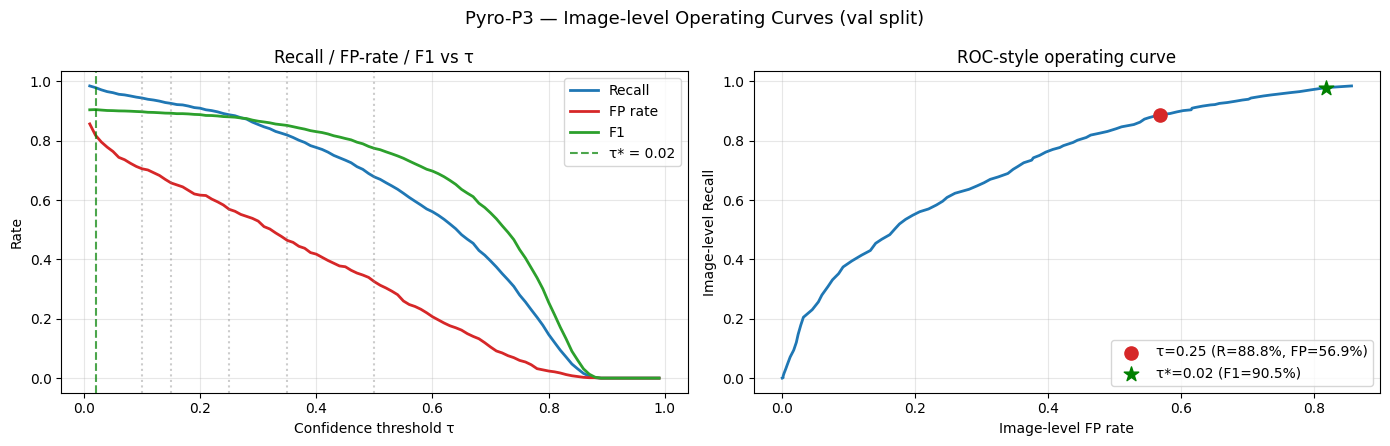

Threshold-sweep plot saved → /kaggle/working/pyro_p3_threshold_sweep.png ✅


In [19]:
# ── Threshold-sweep plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Pyro-P3 — Image-level Operating Curves (val split)", fontsize=13)

taus_plot = [r["tau"]     for r in fine_rows]
recs      = [r["recall"]  for r in fine_rows]
fprs      = [r["fp_rate"] for r in fine_rows]
f1s       = [r["f1"]      for r in fine_rows]

# Left panel: rates vs τ
axes[0].plot(taus_plot, recs, label="Recall",  color="C0", lw=2)
axes[0].plot(taus_plot, fprs, label="FP rate", color="C3", lw=2)
axes[0].plot(taus_plot, f1s,  label="F1",      color="C2", lw=2)
for t in sweep_taus:
    axes[0].axvline(x=t, color="gray", linestyle=":", alpha=0.4)
axes[0].axvline(x=tau_optimal, color="green", linestyle="--", alpha=0.7,
                label=f"τ* = {tau_optimal:.2f}")
axes[0].set_xlabel("Confidence threshold τ")
axes[0].set_ylabel("Rate")
axes[0].set_title("Recall / FP-rate / F1 vs τ")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Right panel: ROC-style — FP rate vs Recall
axes[1].plot(fprs, recs, color="C0", lw=2)
axes[1].scatter([row_025["fp_rate"]], [row_025["recall"]], color="C3", s=90,
                zorder=5,
                label=f"τ=0.25 (R={row_025['recall']*100:.1f}%, FP={row_025['fp_rate']*100:.1f}%)")
axes[1].scatter([best["fp_rate"]], [best["recall"]], color="green", s=120,
                marker="*", zorder=5,
                label=f"τ*={tau_optimal:.2f} (F1={f1_optimal*100:.1f}%)")
axes[1].set_xlabel("Image-level FP rate")
axes[1].set_ylabel("Image-level Recall")
axes[1].set_title("ROC-style operating curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/pyro_p3_threshold_sweep.png", dpi=120)
plt.show()
print("Threshold-sweep plot saved → /kaggle/working/pyro_p3_threshold_sweep.png ✅")

## 10. Results — Ablation Table & Decision

Compare against:
- Vanilla unified (published): recall 88.52%, FP 60.74%
- DCT+AG unified (published): recall 92.05%, FP 58.49% — **+3.53 pp**
- Pyro-P1 solo (loaded from JSON if available)
- Pyro-P3 solo (this run)

**Decision rule.** Δ(Pyro-P3 − Pyro-P1) recall ≥ +1.0 pp → VALIDATED.

In [20]:
# ── Try to load Pyro-P1 baseline JSON (working/ first, then input/) ──
PYRO_P1_JSON_CANDIDATES = [
    "/kaggle/working/pyro_p1_results.json",
    "/kaggle/input/pyro-p1-results/pyro_p1_results.json",
]

# Also scan any /kaggle/input/* subdirectory for the JSON (Kaggle dataset attach)
import glob
for extra in glob.glob("/kaggle/input/*/pyro_p1_results.json"):
    if extra not in PYRO_P1_JSON_CANDIDATES:
        PYRO_P1_JSON_CANDIDATES.append(extra)

pyro_p1_data = None
pyro_p1_src  = None
for cand in PYRO_P1_JSON_CANDIDATES:
    if Path(cand).exists():
        try:
            with open(cand) as f:
                pyro_p1_data = json.load(f)
            pyro_p1_src = cand
            break
        except Exception as e:
            print(f"  Failed to parse {cand}: {e}")

if pyro_p1_data is None:
    print("⚠️  Pyro-P1 JSON not found — using placeholder")
    print("    Searched paths:")
    for c in PYRO_P1_JSON_CANDIDATES:
        print(f"      {c}")
    p1_recall  = None
    p1_fp_rate = None
    p1_f1_025  = None
else:
    print(f"✅ Pyro-P1 JSON loaded from: {pyro_p1_src}")
    p1_recall  = pyro_p1_data.get("img_recall")
    p1_fp_rate = pyro_p1_data.get("img_fp_rate")
    p1_f1_025  = pyro_p1_data.get("f1_025")
    print(f"  P1 img_recall  : {p1_recall*100:.2f}%" if p1_recall  is not None else "  P1 img_recall  : missing")
    print(f"  P1 img_fp_rate : {p1_fp_rate*100:.2f}%" if p1_fp_rate is not None else "  P1 img_fp_rate : missing")
    print(f"  P1 f1_025      : {p1_f1_025*100:.2f}%"  if p1_f1_025  is not None else "  P1 f1_025      : missing")

⚠️  Pyro-P1 JSON not found — using placeholder
    Searched paths:
      /kaggle/working/pyro_p1_results.json
      /kaggle/input/pyro-p1-results/pyro_p1_results.json


In [21]:
# ── ABLATION TABLE ───────────────────────────────────────────────────
print("\n" + "=" * 78)
print(" ABLATION TABLE — PyroNear-SDIS image-level operating point (τ=0.25)")
print("=" * 78)
print(f"  {'Config':<30} {'Recall':>9}  {'FP Rate':>9}  {'F1@0.25':>9}  {'Δ Recall':>10}")
print(f"  {'-'*72}")

def fmt_pct(v):  return f"{v*100:>8.2f}%" if v is not None else "      —"
def fmt_pp(v):   return f"{v:>+8.2f}pp"   if v is not None else "      —"

# Row 1: vanilla unified (published)
print(f"  {'Vanilla (unified, pub.)':<30} {fmt_pct(0.8852):>9}  {fmt_pct(0.6074):>9}  "
      f"{'—':>9}  {'—':>10}")
# Row 2: DCT+AG unified (published)
print(f"  {'DCT+AG (unified, pub.)':<30} {fmt_pct(0.9205):>9}  {fmt_pct(0.5849):>9}  "
      f"{'—':>9}  {'+3.53pp':>10}  (published)")
# Row 3: Pyro-P1 (vanilla solo)
print(f"  {'Pyro-P1 (vanilla solo)':<30} {fmt_pct(p1_recall):>9}  {fmt_pct(p1_fp_rate):>9}  "
      f"{fmt_pct(p1_f1_025):>9}  {'—':>10}")
# Row 4: Pyro-P3 (this run)
delta_recall_pp = (img_recall_025 - p1_recall) * 100 if p1_recall is not None else None
print(f"  {'Pyro-P3 (DCT+WaveletAG)':<30} {fmt_pct(img_recall_025):>9}  "
      f"{fmt_pct(img_fp_rate_025):>9}  {fmt_pct(f1_025):>9}  {fmt_pp(delta_recall_pp):>10}")
print(f"  {'-'*72}")

# Reference: published deltas
if p1_recall is not None:
    delta_fp_pp = (img_fp_rate_025 - p1_fp_rate) * 100
    delta_f1_pp = (f1_025 - p1_f1_025) * 100
    print(f"\n  Pyro-P3 vs Pyro-P1 (isolated WaveletAG contribution on PyroNear):")
    print(f"    Δ Recall  : {delta_recall_pp:+.2f} pp")
    print(f"    Δ FP rate : {delta_fp_pp:+.2f} pp   (lower is better)")
    print(f"    Δ F1@0.25 : {delta_f1_pp:+.2f} pp")
print("=" * 78)


 ABLATION TABLE — PyroNear-SDIS image-level operating point (τ=0.25)
  Config                            Recall    FP Rate    F1@0.25    Δ Recall
  ------------------------------------------------------------------------
  Vanilla (unified, pub.)           88.52%     60.74%          —           —
  DCT+AG (unified, pub.)            92.05%     58.49%          —     +3.53pp  (published)
  Pyro-P1 (vanilla solo)                 —          —          —           —
  Pyro-P3 (DCT+WaveletAG)           88.76%     56.90%     88.06%           —
  ------------------------------------------------------------------------


In [22]:
# ── DECISION CELL ────────────────────────────────────────────────────
print("\n" + "=" * 78)
print(" PYRO-P3 DECISION — WaveletAG validation on PyroNear domain")
print("=" * 78)

print(f"\n  Pyro-P3 recall (τ=0.25)    : {img_recall_025*100:.2f}%")

if p1_recall is not None:
    print(f"  Pyro-P1 baseline (τ=0.25)  : {p1_recall*100:.2f}%")
    print(f"  WaveletAG delta on PyroNear: {delta_recall_pp:+.2f} pp")
else:
    print(f"  Pyro-P1 baseline           : [JSON not loaded — placeholder]")
    print(f"  WaveletAG delta on PyroNear: [pending P1 results]")

print(f"  Threshold for domain-specificity claim: ≥ +1.00 pp")

# ── Verdict ──────────────────────────────────────────────────────────
if p1_recall is None:
    status = "INDETERMINATE"
    reason = "Pyro-P1 JSON not loaded — cannot compute delta"
elif delta_recall_pp >= 1.0:
    status = "VALIDATED"
    reason = f"Δ recall = {delta_recall_pp:+.2f} pp meets ≥ +1.00 pp threshold"
elif delta_recall_pp >= 0.0:
    status = "MARGINAL"
    reason = (f"Δ recall = {delta_recall_pp:+.2f} pp is positive but below "
              f"+1.00 pp threshold — claim is weak")
else:
    status = "FAILED"
    reason = (f"Δ recall = {delta_recall_pp:+.2f} pp is negative — "
              f"WaveletAG does not transfer to PyroNear solo training")

print(f"\n  Status: {status}")
print(f"  Reason: {reason}")
print("=" * 78)


 PYRO-P3 DECISION — WaveletAG validation on PyroNear domain

  Pyro-P3 recall (τ=0.25)    : 88.76%
  Pyro-P1 baseline           : [JSON not loaded — placeholder]
  WaveletAG delta on PyroNear: [pending P1 results]
  Threshold for domain-specificity claim: ≥ +1.00 pp

  Status: INDETERMINATE
  Reason: Pyro-P1 JSON not loaded — cannot compute delta


In [23]:
# ── Save results JSON (spec-required keys + reproducibility extras) ──
pyro_p3_results = {
    # ── Spec-required keys (primary) ──
    "img_recall"      : round(img_recall_025,  4),   # τ=0.25
    "img_fp_rate"     : round(img_fp_rate_025, 4),   # τ=0.25
    "f1_025"          : round(f1_025,          4),   # image-level F1 @ τ=0.25
    "f1_optimal"      : round(f1_optimal,      4),   # image-level F1 @ τ*
    "tau_optimal"     : round(tau_optimal,     3),
    "map50"           : round(map50_val,       4),   # box-level mAP@0.5
    "precision"       : round(img_prec_025,    4),   # image-level precision @ τ=0.25
    "recall_box"      : round(rec_val,         4),   # box-level recall from model.val()
    "params_M"        : round(params_M,        2),
    "epochs_actual"   : epochs_actual,
    "delta_vs_p1_recall": (round(delta_recall_pp / 100, 4)  # store as fraction
                           if delta_recall_pp is not None else None),
    # ── Status (verdict from decision cell) ──
    "status"          : status,
    # ── Reproducibility extras ──
    "phase"           : "Pyro_P3_dct_waveletag_solo",
    "model"           : "YOLO11-S + DCT (L10) + WaveletAttentionGate (L13, L17)",
    "dataset"         : "pyro-sdis solo (PyroNear, nc=1 smoke)",
    "precision_box"   : round(prec_val,        4),
    "map5095"         : round(map5095_val,     4),
    "f1_box"          : round(f1_box,          4),
    "n_val_total"     : n_total,
    "n_val_positive"  : n_positive,
    "n_val_hardneg"   : n_hardneg,
    "sweep"           : [
        {"tau": r["tau"],
         "recall":    round(r["recall"],    4),
         "fp_rate":   round(r["fp_rate"],   4),
         "precision": round(r["precision"], 4),
         "f1":        round(r["f1"],        4)}
        for r in sweep_rows
    ],
    "train_seconds"   : round(train_seconds,   1),
    "cls_pw"          : 0.0,
    "seed"            : 0,
    "imgsz"           : 640,
    "batch"           : 16,
    # ── Baseline reference ──
    "p1_img_recall"   : p1_recall,
    "p1_img_fp_rate"  : p1_fp_rate,
    "p1_f1_025"       : p1_f1_025,
    "p1_json_src"     : pyro_p1_src,
}

json_path = "/kaggle/working/pyro_p3_results.json"
with open(json_path, "w") as f:
    json.dump(pyro_p3_results, f, indent=2)

print(f"Results JSON saved → {json_path} ✅\n")
print(json.dumps(pyro_p3_results, indent=2))

Results JSON saved → /kaggle/working/pyro_p3_results.json ✅

{
  "img_recall": 0.8876,
  "img_fp_rate": 0.569,
  "f1_025": 0.8806,
  "f1_optimal": 0.9051,
  "tau_optimal": 0.02,
  "map50": 0.7396,
  "precision": 0.8737,
  "recall_box": 0.7315,
  "params_M": 9.76,
  "epochs_actual": 50,
  "delta_vs_p1_recall": null,
  "status": "INDETERMINATE",
  "phase": "Pyro_P3_dct_waveletag_solo",
  "model": "YOLO11-S + DCT (L10) + WaveletAttentionGate (L13, L17)",
  "dataset": "pyro-sdis solo (PyroNear, nc=1 smoke)",
  "precision_box": 0.706,
  "map5095": 0.4705,
  "f1_box": 0.7185,
  "n_val_total": 4099,
  "n_val_positive": 3345,
  "n_val_hardneg": 754,
  "sweep": [
    {
      "tau": 0.1,
      "recall": 0.9441,
      "fp_rate": 0.7056,
      "precision": 0.8558,
      "f1": 0.8978
    },
    {
      "tau": 0.15,
      "recall": 0.9259,
      "fp_rate": 0.6578,
      "precision": 0.862,
      "f1": 0.8928
    },
    {
      "tau": 0.25,
      "recall": 0.8876,
      "fp_rate": 0.569,
      "preci

## 11. Save `best.pt` & Cleanup

In [24]:
RUN_DIR = "/kaggle/working/runs/yolo11s_pyro_p3_dct_waveletag"
BEST_PT = f"{RUN_DIR}/weights/best.pt"

# 1. Copy best.pt to top-level
BEST_DST = "/kaggle/working/pyro_p3_dct_waveletag_best.pt"
shutil.copy2(BEST_PT, BEST_DST)
size_mb = Path(BEST_DST).stat().st_size / 1024 / 1024
print(f"best.pt copied → {BEST_DST}  ({size_mb:.1f} MB) ✅")

# 2. Zip run dir
zip_path = "/kaggle/working/pyro_p3_dct_waveletag_run"
shutil.make_archive(zip_path, "zip", RUN_DIR)
zip_size = Path(f"{zip_path}.zip").stat().st_size / 1024 / 1024
print(f"Run zipped → {zip_path}.zip  ({zip_size:.1f} MB) ✅")

# 3. List outputs
print("\n── Output files ──────────────────────────────────────────────")
for f in sorted(Path("/kaggle/working").glob("*")):
    if f.is_file():
        sz = f.stat().st_size / 1024 / 1024
        print(f"  {f.name:<60} {sz:6.1f} MB")

best.pt copied → /kaggle/working/pyro_p3_dct_waveletag_best.pt  (19.3 MB) ✅
Run zipped → /kaggle/working/pyro_p3_dct_waveletag_run.zip  (41.2 MB) ✅

── Output files ──────────────────────────────────────────────
  __notebook__.ipynb                                             25.5 MB
  pyro_p3_dct_waveletag_best.pt                                  19.3 MB
  pyro_p3_dct_waveletag_run.zip                                  41.2 MB
  pyro_p3_results.json                                            0.0 MB
  pyro_p3_threshold_sweep.png                                     0.1 MB
  pyro_p3_training_curves.png                                     0.1 MB
  pyro_solo.yaml                                                  0.0 MB
  yolo11s.pt                                                     18.4 MB
  yolo11s_dct_waveletag_pyro.yaml                                 0.0 MB
  yolo11s_dct_waveletag_pyro_init.pt                             19.3 MB
  yolo26n.pt                                              

In [25]:
# ── Final summary ────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(" PYRO-P3 RUN COMPLETE ✅")
print("=" * 72)
print(f"  Wall time      : {train_seconds/3600:.2f} h   (budget 10 h)")
print(f"  Epochs trained : {epochs_actual}   (target 50)")
print(f"  Status         : {status}")
if p1_recall is not None:
    print(f"  Δ Recall vs P1 : {delta_recall_pp:+.2f} pp")
print()
print("  Key outputs:")
print("    • pyro_p3_dct_waveletag_best.pt        ← model weights")
print("    • pyro_p3_results.json                 ← all metrics + verdict")
print("    • pyro_p3_dct_waveletag_run.zip        ← full training artefacts")
print("    • pyro_p3_training_curves.png          ← training curves")
print("    • pyro_p3_threshold_sweep.png          ← image-level operating curves")
print("=" * 72)


 PYRO-P3 RUN COMPLETE ✅
  Wall time      : 9.78 h   (budget 10 h)
  Epochs trained : 50   (target 50)
  Status         : INDETERMINATE

  Key outputs:
    • pyro_p3_dct_waveletag_best.pt        ← model weights
    • pyro_p3_results.json                 ← all metrics + verdict
    • pyro_p3_dct_waveletag_run.zip        ← full training artefacts
    • pyro_p3_training_curves.png          ← training curves
    • pyro_p3_threshold_sweep.png          ← image-level operating curves
